# Hypotheses Evaluation

This section provides the necessary calculations and figures for the evaluation of computational results in chapter 6.2 - 6.6. Each section of this notebook corresponds to the corresponding section in the thesis.

## Imports

In [1]:
# ignore imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import ttest_1samp, t
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

## Baseline (Chapter 6.2)

### Data Preparation

In [2]:
baseline = pd.read_csv("raw_data/0.csv")

In [3]:
baseline = baseline.groupby(["id", "stage"])
baseline = baseline.agg({
          "agent_0_prices": ["mean", "std", "min", "max"],
          "agent_1_prices": ["mean", "std", "min", "max"],
          "agent_platform_welfare": ["mean", "std"],
          "agent_consumer_welfare": ["mean", "std"],
          "agent_social_welfare": ["mean", "std"],
          "agent_0_demand": ["mean", "std"],
          "agent_1_demand": ["mean", "std"],
          "rel. loss0": ["mean", "std", "max"],
          "rel. loss1": ["mean", "std", "max"],
          "agent_0_installed_base": ["mean", "std"],
          "agent_1_installed_base": ["mean", "std"],
          "agent_0_retention": ["mean", "std"],
          "agent_1_retention": ["mean", "std"],
      })

### Values for Table 6.2

In [4]:
price_mask = baseline.columns.get_level_values(0).isin(
    ["agent_0_prices", "agent_1_prices"]
)

baseline.loc[:, price_mask] = baseline.loc[:, price_mask].round(3)

baseline

agent_0_prices                      agent_1_prices                \
                    mean    std    min    max           mean    std    min   
id  stage                                                                    
0_0 0              0.749  0.006  0.742  0.757          0.750  0.005  0.742   
    1              0.752  0.006  0.745  0.760          0.751  0.006  0.742   
0_1 0              0.753  0.006  0.746  0.763          0.745  0.005  0.736   
0_2 0              0.719  0.006  0.712  0.727          0.720  0.006  0.712   
    1              0.752  0.006  0.744  0.760          0.751  0.006  0.742   
0_3 0              0.643  0.003  0.639  0.647          0.642  0.003  0.638   
    1              0.899  0.012  0.884  0.916          0.904  0.011  0.884   
0_4 0              0.437  0.003  0.434  0.445          0.439  0.003  0.435   
    1              1.134  0.022  1.105  1.164          1.141  0.022  1.109   
0_5 0              0.449  0.002  0.445  0.450          0.433  0.002  0.431   
    1              1.145  0.020  1.122  1.171          1.144  0.020  1.116   

                 agent_platform_welfare            ... rel. loss1            \
             max                   mean       std  ...        std       max   
id  stage                                          ...                        
0_0 0      0.758               0.249433  0.005512  ...   0.004761  0.009335   
    1      0.759               0.251426  0.005559  ...   0.004761  0.009335   
0_1 0      0.753               0.249271  0.005711  ...   0.003308  0.005124   
0_2 0      0.728               0.219503  0.005548  ...   0.002814  0.005286   
    1      0.759               0.251291  0.005488  ...   0.002814  0.005286   
0_3 0      0.646               0.142831  0.003014  ...   0.007039  0.071019   
    1      0.918               0.401638  0.011272  ...   0.007039  0.071019   
0_4 0      0.444              -0.062040  0.002938  ...   0.006804  0.138919   
    1      1.167               0.637764  0.021815  ...   0.006804  0.138919   
0_5 0      0.437              -0.059327  0.001489  ...   0.006677  0.130814   
    1      1.170               0.644792  0.019935  ...   0.006677  0.130814   

          agent_0_installed_base           agent_1_installed_base            \
                            mean       std                   mean       std   
id  stage                                                                     
0_0 0                   0.500000  0.000000               0.500000  0.000000   
    1                   0.500567  0.002192               0.499433  0.002192   
0_1 0                   0.600000  0.000000               0.400000  0.000000   
0_2 0                   0.500000  0.000000               0.500000  0.000000   
    1                   0.500750  0.002588               0.499250  0.002588   
0_3 0                   0.500000  0.000000               0.500000  0.000000   
    1                   0.499150  0.002585               0.500850  0.002585   
0_4 0                   0.500000  0.000000               0.500000  0.000000   
    1                   0.500567  0.002410               0.499433  0.002410   
0_5 0                   0.600000  0.000000               0.400000  0.000000   
    1                   0.551283  0.002526               0.448717  0.002526   

          agent_0_retention               agent_1_retention                
                       mean           std              mean           std  
id  stage                                                                  
0_0 0                   NaN           NaN               NaN           NaN  
    1              0.993628  3.893509e-03               1.0  1.884864e-08  
0_1 0                   NaN           NaN               NaN           NaN  
0_2 0                   NaN           NaN               NaN           NaN  
    1              0.993845  4.487425e-03               1.0  2.513152e-08  
0_3 0                   NaN           NaN               NaN           NaN  
    1              

## Experiment A1 (Chapter 6.3)

In [5]:
A1 = pd.read_csv('raw_data/A1.csv')

In [6]:
A1_grouped = (
    A1.groupby(["id", "stage"])
      .agg({
          "agent_0_prices": ["mean", "std", "min", "max"],
          "agent_1_prices": ["mean", "std", "min", "max"],
          "agent_platform_welfare": ["mean", "std"],
          "agent_consumer_welfare": ["mean", "std"],
          "agent_social_welfare": ["mean", "std"],
          "agent_0_demand": ["mean", "std"],
          "agent_1_demand": ["mean", "std"],
          "rel. loss0": ["mean", "std", "max"],
          "rel. loss1": ["mean", "std", "max"],
          "agent_0_installed_base": ["mean", "std"],
          "agent_1_installed_base": ["mean", "std"],
          "agent_0_retention": ["mean", "std"],
          "agent_1_retention": ["mean", "std"],
      })
)

### Regression for Pricing Hypothesis

In [7]:
# Parameter mapping
param_map = pd.DataFrame({
    "id": [f"A1_{i}" for i in range(9)],
    "switching_cost": [0.0, 0.045, 0.09] * 3,
    "membership_benefit": [0.0] * 3 + [0.045] * 3 + [0.09] * 3
})

# Stage 0 only

reg_df = (
    A1[A1["stage"] == 0]
    .merge(param_map, on="id")
    .copy()
)
reg_df["price"] = (
    reg_df["agent_0_prices"] +
    reg_df["agent_1_prices"]
) / 2

model = smf.ols(
    "price ~ switching_cost * membership_benefit + C(seed)",
    data=reg_df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     2094.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.49e-91
Time:                        16:42:58   Log-Likelihood:                 372.60
No. Observations:                  90   AIC:                            -719.2
Df Residuals:                      77   BIC:                            -686.7
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Figure 6.6

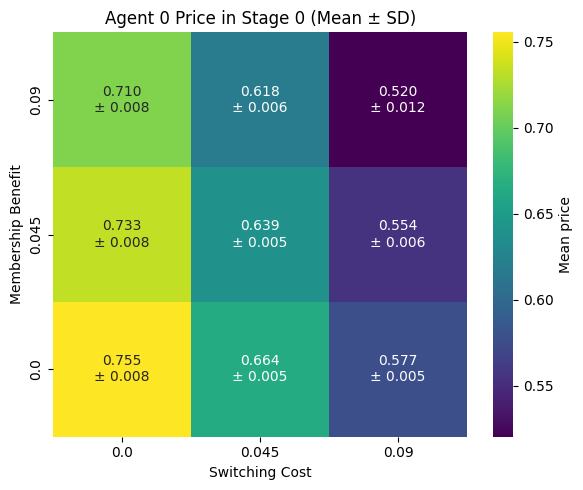

In [8]:
param_map = pd.DataFrame({
    "id": [f"A1_{i}" for i in range(9)],
    "switching_cost": [0.0, 0.045, 0.09] * 3,
    "membership_benefit": [0.0] * 3 + [0.045] * 3 + [0.09] * 3
})

plot_df = (
    A1_grouped.loc[pd.IndexSlice[:, 0],
            [("agent_0_prices", "mean"),
             ("agent_0_prices", "std")]]
       .reset_index()
)

plot_df.columns = [
    "id", "stage", "price_mean", "price_std"
]

plot_df = plot_df.merge(param_map, on="id")

plot_df["label"] = (
    plot_df["price_mean"].map("{:.3f}".format)
    + "\n± "
    + plot_df["price_std"].map("{:.3f}".format)
)

means = plot_df.pivot(
    index="membership_benefit",
    columns="switching_cost",
    values="price_mean"
).sort_index(ascending=False)

labels = plot_df.pivot(
    index="membership_benefit",
    columns="switching_cost",
    values="label"
).sort_index(ascending=False)

plt.figure(figsize=(6, 5))

sns.heatmap(
    means,
    annot=labels,
    fmt="",
    cmap="viridis",
    cbar_kws={"label": "Mean price"}
)

plt.title("Agent 0 Price in Stage 0 (Mean ± SD)")
plt.xlabel("Switching Cost")
plt.ylabel("Membership Benefit")
plt.tight_layout()
plt.show()

Due to symmetry in initial conditions, showing agent 0 results is sufficient.

### Welfare Evaluation

Calculate welfare from raw data.

In [9]:
u = 19 / 12
transport_cost = 0.25

param_map = pd.DataFrame({
    "id": [f"A1_{i}" for i in range(10)],
    "switching_cost": [0.0, 0.045, 0.09] * 3 + [0.1],
    "membership_benefit": [0.0] * 3 + [0.045] * 3 + [0.09] * 3 + [0.1],
})

A1 = (
    A1.merge(param_map, on="id", validate="many_to_one")
      .sort_values(["id", "seed", "stage"])
)

groups = A1.groupby(["id", "seed"])

previous_demand_0 = groups["agent_0_demand"].shift()
previous_demand_1 = groups["agent_1_demand"].shift()

switchers = (
    previous_demand_0 * (1 - A1["agent_0_retention"].fillna(1))
    + previous_demand_1 * (1 - A1["agent_1_retention"].fillna(1))
).fillna(0)

A1["agent_consumer_welfare"] = (
    A1["agent_0_demand"]
    * (
        u
        - A1["agent_0_prices"]
        + A1["membership_benefit"] * A1["agent_0_installed_base"]
    )
    + A1["agent_1_demand"]
    * (
        u
        - A1["agent_1_prices"]
        + A1["membership_benefit"] * A1["agent_1_installed_base"]
    )
    - 0.5 * transport_cost
    * (A1["agent_0_demand"]**2 + A1["agent_1_demand"]**2)
    - A1["switching_cost"] * switchers
)

A1["agent_social_welfare"] = (
    A1["agent_platform_welfare"]
    + A1["agent_consumer_welfare"]
)

### Regression for Consumer, Platform and Social Welfare

Note that Social Welfare was not included in the thesis. We stil include this results in the notebook.

In [10]:
reg_df = (
    A1[A1["id"] != "A1_9"]
    .groupby(
        ["id", "seed", "switching_cost", "membership_benefit"],
        as_index=False,
    )
    .agg(
        consumer_welfare=("agent_consumer_welfare", "sum"),
        platform_welfare=("agent_platform_welfare", "sum"),
        social_welfare=("agent_social_welfare", "sum"),
    )
)

welfare_metrics = [
    "consumer_welfare",
    "platform_welfare",
    "social_welfare",
]

models = {}

for metric in welfare_metrics:
    models[metric] = smf.ols(
        f"{metric} ~ switching_cost * membership_benefit + C(seed)",
        data=reg_df,
    ).fit(cov_type="HC3")

    print(f"\n{'=' * 20} {metric} {'=' * 20}")
    print(models[metric].summary())



==================== consumer_welfare ====================
                            OLS Regression Results                            
Dep. Variable:       consumer_welfare   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     383.8
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.95e-63
Time:                        16:42:59   Log-Likelihood:                 227.24
No. Observations:                  90   AIC:                            -428.5
Df Residuals:                      77   BIC:                            -396.0
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

### Figure 6.7 and 6.8

Requires adjusting of labels and chosen columns.

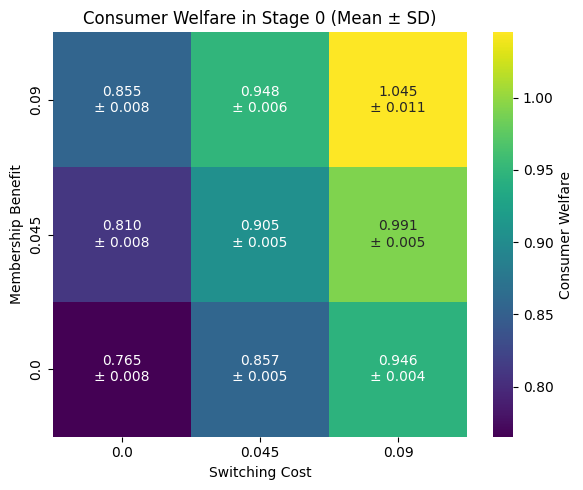

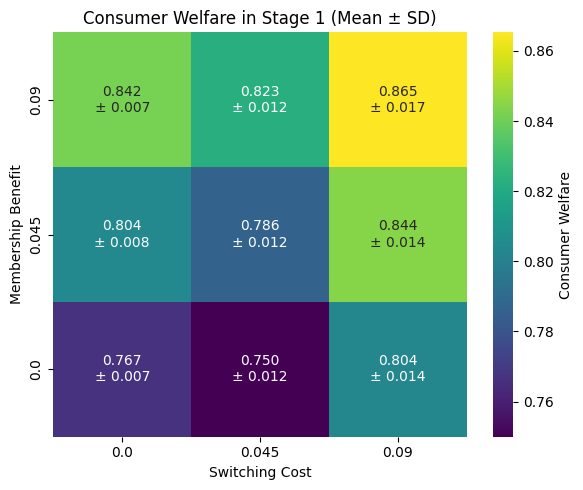

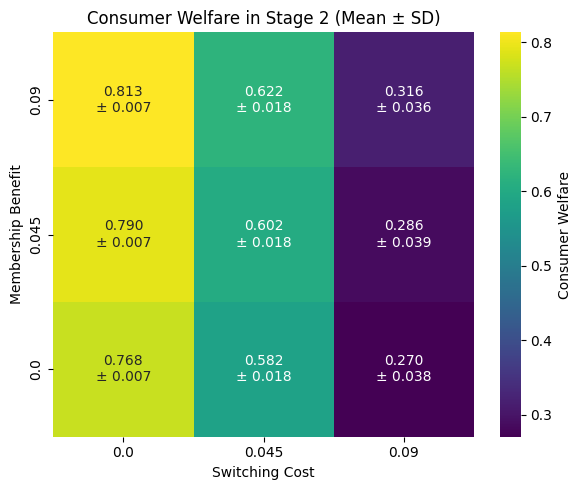

In [11]:
for stage in (0, 1, 2):
    plot_df = (
        A1_grouped.loc[
            pd.IndexSlice[:, stage],
            [
                ("agent_consumer_welfare", "mean"),
                ("agent_consumer_welfare", "std")
            ]
        ]
        .reset_index()
    )
    plot_df.columns = ["id", "stage", "cw_mean", "cw_std"]

    plot_df = plot_df[plot_df["id"] != "A1_9"].copy()

    plot_df.columns = [
        "id", "stage", "cw_mean", "cw_std"
    ]

    plot_df = plot_df.merge(param_map, on="id")

    plot_df["label"] = (
        plot_df["cw_mean"].map("{:.3f}".format)
        + "\n± "
        + plot_df["cw_std"].map("{:.3f}".format)
    )

    means = plot_df.pivot(
        index="membership_benefit",
        columns="switching_cost",
        values="cw_mean"
    ).sort_index(ascending=False)

    labels = plot_df.pivot(
        index="membership_benefit",
        columns="switching_cost",
        values="label"
    ).sort_index(ascending=False)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        means,
        annot=labels,
        fmt="",
        cmap="viridis",
        cbar_kws={"label": "Consumer Welfare"}
    )

    plt.title(f"Consumer Welfare in Stage {stage} (Mean ± SD)")
    plt.xlabel("Switching Cost")
    plt.ylabel("Membership Benefit")
    plt.tight_layout()
    plt.show()

### Table 6.3

In [12]:
A1[A1["id"] == "A1_9"].groupby(["id", "stage"]).agg({"agent_0_prices": ["mean", "std"], "agent_1_prices": ["mean", "std"], 
                                                    "agent_0_retention": ["mean", "std"], "agent_1_retention": ["mean", "std"]}).reset_index()

id stage agent_0_prices           agent_1_prices            \
                        mean       std           mean       std   
0  A1_9     0       0.000000  0.000000       0.000000  0.000000   
1  A1_9     1       1.439070  0.002755       1.438724  0.002496   
2  A1_9     2       1.450542  0.001921       1.449079  0.001007   

  agent_0_retention      agent_1_retention                
               mean  std              mean           std  
0               NaN  NaN               NaN           NaN  
1               1.0  0.0               1.0  2.513152e-08  
2               1.0  0.0               1.0  2.513152e-08

## Experiment A2 (6.4)

In [13]:
A2 = pd.read_csv('raw_data/A2.csv')
A2= A2[~((A2["id"] == "A2_8") & (A2["seed"] == 8))] #exclude unstable seed, see stability_analysis.ipynb

We first define our evaluation metric.

In [14]:
A2["asymmetry"] = (
    A2["agent_0_installed_base"] -
    A2["agent_1_installed_base"]
).abs()

### Regression

In [15]:
A2_param_map = pd.DataFrame({
    "id": [f"A2_{i}" for i in range(9)],
    "switching_cost": [0.0, 0.045, 0.09] * 3,
    "membership_benefit": (
        [0.0] * 3
        + [0.75] * 3
        + [1.0] * 3
    ),
})

# Initial asymmetry
initial = (
    A2[A2["stage"] == 0]
    [["id", "seed", "asymmetry"]]
    .rename(columns={"asymmetry": "initial_asymmetry"})
)

# Final asymmetry
final = (
    A2[A2["stage"] == A2["stage"].max()]
    [["id", "seed", "asymmetry"]]
    .rename(columns={"asymmetry": "final_asymmetry"})
)

# Match initial and final observations
reg_df = (
    initial
    .merge(
        final,
        on=["id", "seed"],
        validate="one_to_one",
    )
    .merge(
        A2_param_map,
        on="id",
        how="inner",  # excludes A1_9 corner case
        validate="many_to_one",
    )
)

reg_df["amplification"] = (
    reg_df["final_asymmetry"]
    - reg_df["initial_asymmetry"]
)

model = smf.ols(
    """
    amplification
    ~ switching_cost * membership_benefit
    + C(seed)
    """,
    data=reg_df,
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          amplification   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     217.6
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.20e-53
Time:                        16:42:59   Log-Likelihood:                 54.868
No. Observations:                  89   AIC:                            -83.74
Df Residuals:                      76   BIC:                            -51.38
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Figure 6.9

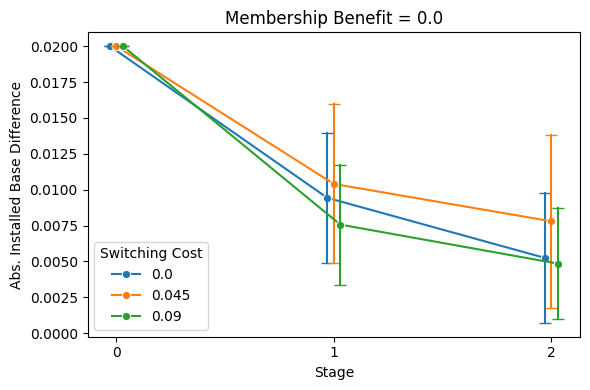

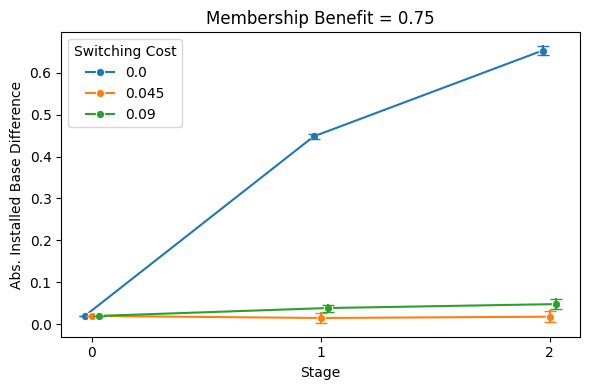

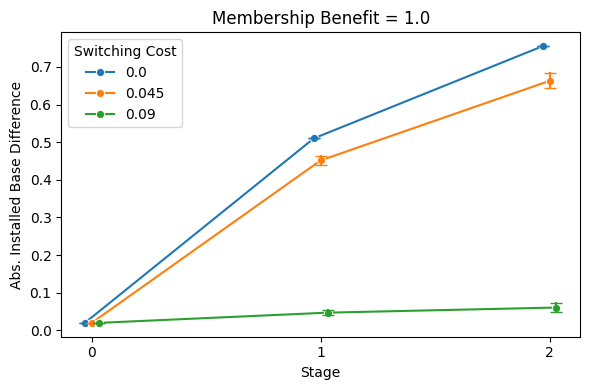

In [16]:
# Parameter mapping; A1_9 is excluded (corner configuration ommited from thesis due to irrelevance)
param_map = pd.DataFrame({
    "id": [f"A2_{i}" for i in range(9)],
    "switching_cost": [0.0, 0.045, 0.09] * 3,
    "membership_benefit": [0.0] * 3 + [0.75] * 3 + [1.0] * 3,
})

data = A2.merge(param_map, on="id", how="inner")

switching_cost_colors = {
    0.000: "tab:blue",
    0.045: "tab:orange",
    0.090: "tab:green",
}

offsets = {
    0.000: -0.03,
    0.045:  0.00,
    0.090:  0.03,
}

for membership_benefit in sorted(
    data["membership_benefit"].unique()
):
    subset = data[
        data["membership_benefit"] == membership_benefit
    ].copy()

    subset["stage_offset"] = (
        subset["stage"]
        + subset["switching_cost"].map(offsets)
    )

    plt.figure(figsize=(6, 4))

    sns.lineplot(
        data=subset,
        x="stage_offset",
        y="asymmetry",
        hue="switching_cost",
        estimator="mean",
        errorbar="sd",
        err_style="bars",
        err_kws={"capsize": 4},
        marker="o",
        palette=switching_cost_colors,
    )

    plt.title(
        f"Membership Benefit = {membership_benefit}"
    )
    plt.xlabel("Stage")
    plt.ylabel("Abs. Installed Base Difference")
    plt.xticks([0, 1, 2], [0, 1, 2])
    plt.legend(title="Switching Cost")
    plt.tight_layout()
    plt.show()




### Figure 6.10

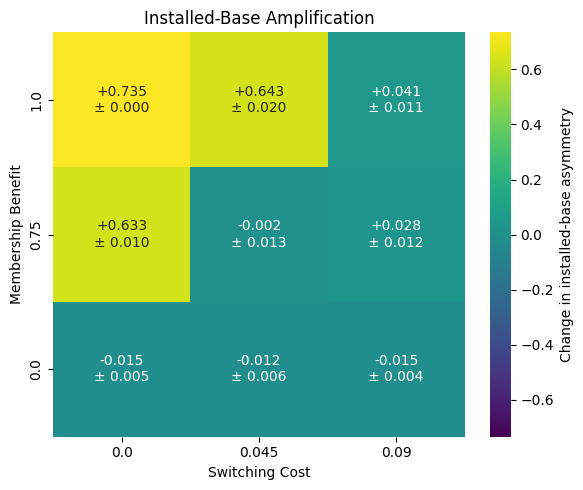

In [17]:
first_stage = data["stage"].min()
final_stage = data["stage"].max()

seed_results = (
    data.pivot_table(
        index=[
            "id",
            "seed",
            "switching_cost",
            "membership_benefit",
        ],
        columns="stage",
        values="asymmetry",
        aggfunc="mean",
    )
    .reset_index()
)

seed_results["amplification"] = (
    seed_results[final_stage] - seed_results[first_stage]
)

summary = (
    seed_results.groupby(
        ["switching_cost", "membership_benefit"]
    )["amplification"]
    .agg(["mean", "std"])
    .reset_index()
)

summary["label"] = (
    summary["mean"].map("{:+.3f}".format)
    + "\n± "
    + summary["std"].map("{:.3f}".format)
)

means = summary.pivot(
    index="membership_benefit",
    columns="switching_cost",
    values="mean",
).sort_index(ascending=False)

labels = summary.pivot(
    index="membership_benefit",
    columns="switching_cost",
    values="label",
).sort_index(ascending=False)

limit = max(0.01, np.nanmax(np.abs(means.to_numpy())))

plt.figure(figsize=(6, 5))

sns.heatmap(
    means,
    annot=labels,
    fmt="",
    cmap="viridis",
    center=0,
    vmin=-limit,
    vmax=limit,
    cbar_kws={"label": "Change in installed-base asymmetry"},
)

plt.title("Installed-Base Amplification")
plt.xlabel("Switching Cost")
plt.ylabel("Membership Benefit")
plt.tight_layout()
plt.show()

## Experiment B (6.5)

In [18]:
B = pd.read_csv("raw_data/B.csv")

### Figure 6.10

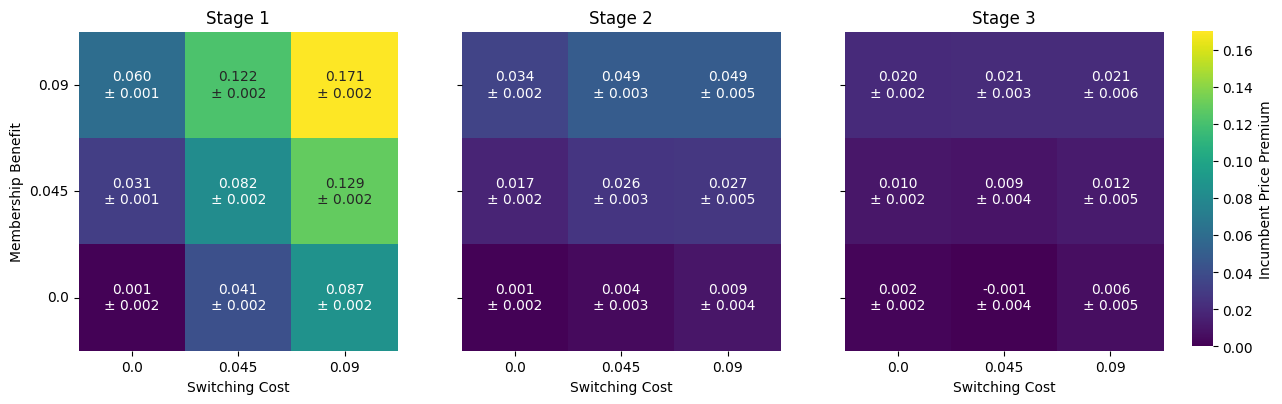

In [19]:
from scipy.stats import t
# Parameter mapping; A1_10 is excluded
param_map_B = pd.DataFrame({
    "id": [f"B_{i}" for i in range(0, 9)],
    "switching_cost": [
        0.000, 0.000, 0.000,
        0.045, 0.045, 0.045,
        0.090, 0.090, 0.090,
    ],
    "membership_benefit": [
        0.000, 0.045, 0.090,
        0.000, 0.045, 0.090,
        0.000, 0.045, 0.090,
    ],
})

df_plot = (
    B[B["id"].isin(param_map_B["id"])]
    .copy()
)

df_plot["price_advantage"] = (
    df_plot["agent_0_prices"]
    - df_plot["agent_1_prices"]
)

plot_df = (
    df_plot.groupby(["id", "stage"])["price_advantage"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .merge(param_map_B, on="id")
)

plot_df["label"] = (
    plot_df["mean"].map("{:.3f}".format)
    + "\n± "
    + plot_df["std"].map("{:.3f}".format)
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 4.5),
    sharey=True,
)

# Separate axis for colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])

for i, (ax, stage) in enumerate(zip(axes, [0, 1, 2])):
    stage_df = plot_df[plot_df["stage"] == stage]

    means = stage_df.pivot(
        index="membership_benefit",
        columns="switching_cost",
        values="mean",
    ).sort_index(ascending=False)

    labels = stage_df.pivot(
        index="membership_benefit",
        columns="switching_cost",
        values="label",
    ).sort_index(ascending=False)

    sns.heatmap(
        means,
        annot=labels,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=0.17,
        square=True,
        ax=ax,
        cbar=(i == 2),
        cbar_ax=cbar_ax if i == 2 else None,
        cbar_kws={"label": "Incumbent Price Premium"},
    )

    ax.set_title(f"Stage {stage+1}")
    ax.set_xlabel("Switching Cost")
    ax.set_ylabel(
        "Membership Benefit" if i == 0 else ""
    )
    ax.tick_params(axis="both", rotation=0)

plt.subplots_adjust(right=0.90)
plt.show()

### Regression for price premium

In [20]:
# Use all raw Stage 0 observations
reg_df = (
    B[B["stage"] == 0]
    .merge(param_map_B, on="id", how="inner")
    .copy()
)

# Incumbent price premium
reg_df["price_advantage"] = (
    reg_df["agent_0_prices"]
    - reg_df["agent_1_prices"]
)

model = smf.ols(
    """
    price_advantage
    ~ switching_cost * membership_benefit
    + C(seed)
    """,
    data=reg_df,
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        price_advantage   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     5471.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          1.43e-107
Time:                        16:42:59   Log-Likelihood:                 431.49
No. Observations:                  90   AIC:                            -837.0
Df Residuals:                      77   BIC:                            -804.5
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Table 6.4

In [21]:
B[B["id"]=="B_9"].groupby(["id", "stage"]).agg({"agent_0_prices": ["mean", "std"], "agent_0_demand": ["mean", "std"], "agent_1_prices": ["mean", "std"], "agent_1_demand": ["mean", "std"], "rel. loss0": ["mean", "std"], "rel. loss1": ["mean", "std"]}).reset_index()

id stage agent_0_prices      agent_0_demand      agent_1_prices       \
                       mean  std           mean  std           mean  std   
0  B_9     0            2.0  0.0            1.0  0.0       0.058138  0.0   
1  B_9     1            2.0  0.0            1.0  0.0       0.111223  0.0   
2  B_9     2            2.0  0.0            1.0  0.0       0.143499  0.0   

  agent_1_demand      rel. loss0      rel. loss1       
            mean  std       mean  std       mean  std  
0            0.0  0.0        0.0  0.0        0.0  0.0  
1            0.0  0.0        0.0  0.0        0.0  0.0  
2            0.0  0.0        0.0  0.0        0.0  0.0

## Experiment C (6.6)

In [22]:
C = pd.read_csv('raw_data/C.csv')


Construct evaluation metric.

In [23]:
SH_map = pd.DataFrame({
    "id": ["A2_3", "A2_6", "A2_7"],
    "switching_cost": [0.000, 0.000, 0.045],
    "membership_benefit": [0.750, 1.000, 1.000],
})

MH_map = pd.DataFrame({
    "id": ["C_0", "C_1", "C_2"],
    "switching_cost": [0.000, 0.000, 0.045],
    "membership_benefit": [0.750, 1.000, 1.000],
})


def amplification(data, parameter_map, name):
    data = data.merge(parameter_map, on="id")

    data["asymmetry"] = (
        data["agent_0_installed_base"]
        - data["agent_1_installed_base"]
    ).abs()

    data = data.pivot_table(
        index=[
            "seed",
            "switching_cost",
            "membership_benefit",
        ],
        columns="stage",
        values="asymmetry",
    ).reset_index()

    data[name] = data[2] - data[0]

    return data[
        [
            "seed",
            "switching_cost",
            "membership_benefit",
            name,
        ]
    ]


SH_results = amplification(A2, SH_map, "SH")
MH_results = amplification(C, MH_map, "MH")

paired = SH_results.merge(
    MH_results,
    on=[
        "seed",
        "switching_cost",
        "membership_benefit",
    ],
)

paired["SH_minus_MH"] = paired["SH"] - paired["MH"]

### Holm Significance Test

In [24]:
test_rows = []

for (
    switching_cost,
    membership_benefit,
), group in paired.groupby(
    ["switching_cost", "membership_benefit"]
):
    differences = group["SH_minus_MH"].dropna()
    n = len(differences)

    statistic, p_value = ttest_1samp(
        differences,
        popmean=0,
    )

    mean_difference = differences.mean()
    se = differences.std(ddof=1) / np.sqrt(n)
    critical_value = t.ppf(0.975, df=n - 1)

    test_rows.append({
        "switching_cost": switching_cost,
        "membership_benefit": membership_benefit,
        "n": n,
        "SH_mean": group["SH"].mean(),
        "MH_mean": group["MH"].mean(),
        "SH_minus_MH": mean_difference,
        "CI_low": mean_difference - critical_value * se,
        "CI_high": mean_difference + critical_value * se,
        "t_statistic": statistic,
        "p_value": p_value,
    })

test_results = pd.DataFrame(test_rows)

test_results["p_value_Holm"] = multipletests(
    test_results["p_value"],
    method="holm",
)[1]

display(test_results.round(4))

,switching_cost,membership_benefit,n,SH_mean,MH_mean,SH_minus_MH,CI_low,CI_high,t_statistic,p_value,p_value_Holm
0,0.000,0.75,10,0.6329,0.6089,0.0240,0.0198,0.0283,12.7056,0.0,0.0
1,0.000,1.00,10,0.7350,0.6560,0.0790,0.0773,0.0807,105.4242,0.0,0.0
2,0.045,1.00,10,0.6428,-0.0081,0.6508,0.6340,0.6677,87.3987,0.0,0.0


### Figure 6.11

In [25]:
SH_plot = A2.merge(SH_map, on="id")
SH_plot["mode"] = "Single-homing"

MH_plot = C.merge(MH_map, on="id")
MH_plot["mode"] = "Multi-homing"

plot_data = pd.concat(
    [SH_plot, MH_plot],
    ignore_index=True,
)

plot_data["installed_base_gap"] = (
    plot_data["agent_0_installed_base"]
    - plot_data["agent_1_installed_base"]
).abs() * 100

C_summary = (
    plot_data.groupby([
        "switching_cost",
        "membership_benefit",
        "mode",
        "stage",
    ])["installed_base_gap"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

C_summary["ci"] = (
    t.ppf(0.975, C_summary["n"] - 1)
    * C_summary["std"]
    / np.sqrt(C_summary["n"])
)

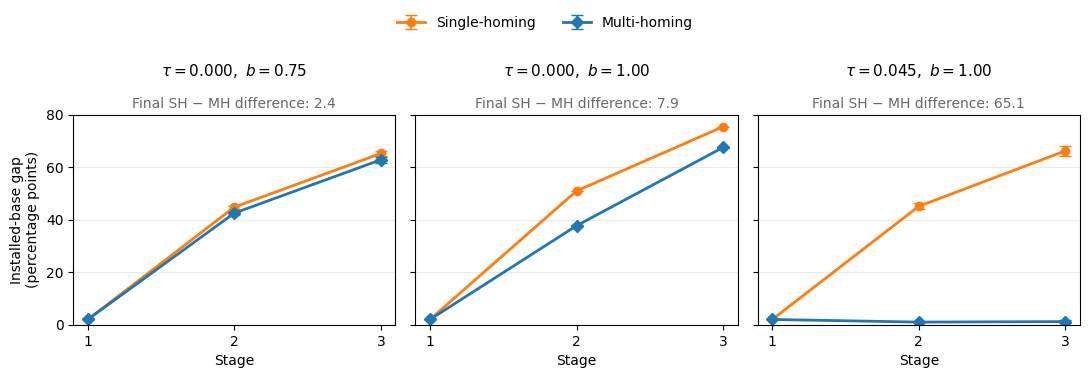

In [26]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(11, 4),
    sharex=True,
    sharey=True,
)

colors = {
    "Single-homing": "tab:orange",
    "Multi-homing": "tab:blue",
}

markers = {
    "Single-homing": "o",
    "Multi-homing": "D",
}

configurations = [
    (0.000, 0.750),
    (0.000, 1.000),
    (0.045, 1.000),
]

for ax, (tau, benefit) in zip(axes, configurations):
    panel = C_summary[
        np.isclose(C_summary["switching_cost"], tau)
        & np.isclose(C_summary["membership_benefit"], benefit)
    ]

    for mode in ["Single-homing", "Multi-homing"]:
        line = (
            panel[panel["mode"] == mode]
            .sort_values("stage")
        )

        ax.errorbar(
            line["stage"] +1 ,
            line["mean"],
            yerr=line["std"],
            color=colors[mode],
            marker=markers[mode],
            linewidth=2,
            markersize=6,
            capsize=4,
            elinewidth=1.2,
            label=mode,
        )

    final_stage = panel["stage"].max()

    final = (
        panel[panel["stage"] == final_stage]
        .set_index("mode")["mean"]
    )

    final_difference = (
        final["Single-homing"]
        - final["Multi-homing"]
    )

    ax.set_title(
        rf"$\tau={tau:.3f},\ b={benefit:.2f}$",
        fontsize=11,
        pad=28,
    )

    ax.text(
        0.5,
        1.02,
        f"Final SH − MH difference: {final_difference:.1f}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        color="dimgray",
    )

    ax.set_xlabel("Stage")
    ax.set_xticks([1, 2, 3])
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel(
    "Installed-base gap\n(percentage points)"
)
axes[0].set_ylim(0, 80)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()